In [1]:
!nvidia-smi

Wed Aug 13 19:05:07 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 566.36                 Driver Version: 566.36         CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   45C    P0             20W /   95W |     149MiB /   6144MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# STEP 1: Import Required Libraries

In [2]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import random
from PIL import Image
import os
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Check if CUDA is available
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")
torch.manual_seed(0)

Using device: cuda
PyTorch version: 2.8.0+cu126


# STEP 2: Load and Explore the Dataset

In [4]:
path = "./competition/"
print("Path to dataset files:", path)

DATA_DIR = os.path.join(path, "image")
TRAIN_CSV = os.path.join(path, "train.csv")
SAMPLE_SUBMISSION = os.path.join(path, "sample_submission.csv")

LABELS = ['Ink scenery', 'comic', 'cyberpunk', 'futuristic UI', 'lowpoly', 'oil painting',
          'pixel', 'realistic', 'steampunk', 'water color']
LABEL2IDX = {label: idx for idx, label in enumerate(LABELS)}
IDX2LABEL = {idx: label for label, idx in LABEL2IDX.items()}

Path to dataset files: ./competition/


# STEP 3: Custom Dataset Class

In [5]:
class ArtDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None, is_test=False):
        self.data = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.transform = transform
        self.is_test = is_test
        self.has_labels = 'style' in self.data.columns and not is_test

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        uuid = self.data.iloc[idx]['uuid']
        img_path = os.path.join(self.img_dir, f"{uuid}.png")

        try:
            image = Image.open(img_path).convert("RGB")
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            image = Image.new("RGB", (224, 224), (0, 0, 0))

        if self.transform:
            image = self.transform(image)

        if self.has_labels:
            style = self.data.iloc[idx]['style']
            label = LABEL2IDX[style]
            return image, label
        else:
            return image, uuid


# STEP 5: Data Transforms and Augmentation

In [6]:
def pad_to_square(img, fill=0):
    w, h = img.size
    max_wh = max(w, h)
    pad_w = (max_wh - w) // 2
    pad_h = (max_wh - h) // 2
    padding = (pad_w, pad_h, max_wh - w - pad_w, max_wh - h - pad_h)
    return transforms.functional.pad(img, padding, fill=fill)

In [7]:
# ImageNet
mean=[0.485, 0.456, 0.406]
std=[0.229, 0.224, 0.225]
# b0
# size = (224, 224)
# b3
size = (300, 300)

# For this Data
# mean=[0.3812, 0.3990, 0.4013]
# std=[0.2665, 0.2686, 0.2547]

train_transforms = transforms.Compose([
	transforms.Lambda(pad_to_square),
    transforms.Resize(size=size),
	transforms.RandomHorizontalFlip(p=0.5),
	transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
	transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# Define transforms for validation/test (no augmentation)
val_transforms = transforms.Compose([
	transforms.Lambda(pad_to_square),
    transforms.Resize(size=size),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

print("Data transforms defined:")
print("- Training: Pad, Resize, Rotation, Flip, ColorJitter, Normalize")
print("- Validation: Pad, Resize, Normalize only")

Data transforms defined:
- Training: Pad, Resize, Rotation, Flip, ColorJitter, Normalize
- Validation: Pad, Resize, Normalize only


# STEP 6: Clean Data

In [8]:
# Load the training data and split it into train/validation
train_data = pd.read_csv(TRAIN_CSV)

# Filter only known styles
original_len = len(train_data)
train_data = train_data[train_data['style'].isin(LABEL2IDX.keys())].reset_index(drop=True)
filtered_len = len(train_data)

# STEP 6: Create Data Loaders

In [9]:
# Split the data into train and validation sets
train_df, val_df = train_test_split(
    train_data, 
    test_size=0.3,  # 30% for validation
    random_state=42, 
    stratify=train_data['style']  # Ensure balanced split across classes
)

print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Class distribution in training set:")
print(train_df['style'].value_counts())

Training samples: 4529
Validation samples: 1942
Class distribution in training set:
style
oil painting     766
futuristic UI    761
Ink scenery      659
water color      598
pixel            487
realistic        414
steampunk        329
lowpoly          254
cyberpunk        169
comic             92
Name: count, dtype: int64


In [10]:
# Save the split data to temporary CSV files
train_df.to_csv('temp_train.csv', index=False)
val_df.to_csv('temp_val.csv', index=False)

# Create datasets
train_dataset = ArtDataset('temp_train.csv', DATA_DIR, train_transforms)
val_dataset = ArtDataset('temp_val.csv', DATA_DIR, val_transforms)
test_dataset = ArtDataset(SAMPLE_SUBMISSION, DATA_DIR, val_transforms, is_test=True)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train loader batches: {len(train_loader)}")
print(f"Validation loader batches: {len(val_loader)}")
print(f"Test loader batches: {len(test_loader)}")

Train loader batches: 142
Validation loader batches: 61
Test loader batches: 45


# STEP 7: Visualize Sample Data

In [11]:
def imshow(tensor, title=None):
    """Display a tensor as an image"""
    # Denormalize the image
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    image = tensor.clone().detach()
    image = image.numpy().transpose((1, 2, 0))
    image = std * image + mean
    image = np.clip(image, 0, 1)
    
    plt.imshow(image)
    if title:
        plt.title(title)
    plt.axis('off')


In [12]:
def show_images_from_class(data_loader, target_class, class_names, num_images=9):
    """
    Show a number of images from a specific class.
    target_class: class name or class index
    """
    # If target_class is a name, convert to index
    if isinstance(target_class, str):
        target_class_idx = class_names.index(target_class)
    else:
        target_class_idx = target_class

    images_of_class = []

    # Collect all images of that class
    for images, labels in data_loader:
        for img, label in zip(images, labels):
            if label.item() == target_class_idx:
                images_of_class.append(img)
        if len(images_of_class) >= num_images:
            break

    # Randomly select the images to display
    selected_images = random.sample(images_of_class, min(num_images, len(images_of_class)))

    # Show them in a 3x3 grid
    plt.figure(figsize=(9, 9))
    for i, img in enumerate(selected_images):
        plt.subplot(4, 4, i + 1)
        imshow(img)
        plt.axis('off')

    plt.suptitle(f"{class_names[target_class_idx]} - {len(selected_images)} samples", fontsize=16)
    plt.show()

In [13]:
visual_data = ArtDataset(TRAIN_CSV, DATA_DIR, val_transforms)

visual_loader = DataLoader(visual_data, batch_size=32, shuffle=True)

In [ ]:
print(LABELS)
show_images_from_class(visual_loader, "pixel", LABELS, num_images=12)

# STEP 8: Model Architecture

In [14]:
class EfficientNetClassifier(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super(EfficientNetClassifier, self).__init__()
        
        # self.backbone = models.efficientnet_b0(pretrained=pretrained)
        self.backbone = models.efficientnet_b3(pretrained=pretrained)
        num_features = self.backbone.classifier[1].in_features

        self.backbone.classifier = nn.Sequential(
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        return self.backbone(x)

num_classes = len(LABEL2IDX)

# Create model
model = EfficientNetClassifier(num_classes, pretrained=True)
# model = models.convnext_base(pretrained=True)
# model.classifier[2] = nn.Linear(model.classifier[2].in_features, 10)

# Move model to device
model = model.to(device)

# Display model architecture
print(f"Model created with {num_classes} classes")
print(f"Model moved to {device}")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Model created with 10 classes
Model moved to cuda
Total parameters: 11,092,274
Trainable parameters: 11,092,274


# STEP 9: Loss Function and Optimizer

In [15]:
# Define loss function
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(LABELS),
    y=LABELS
)
class_weights = torch.tensor(weights, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Define optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# Learning rate scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

print("Training setup:")
print(f"Loss function: CrossEntropyLoss")
print(f"Optimizer: Adam (lr=0.001, weight_decay=1e-4)")
print(f"Scheduler: StepLR (step_size=10, gamma=0.1)")

Training setup:
Loss function: CrossEntropyLoss
Optimizer: Adam (lr=0.001, weight_decay=1e-4)
Scheduler: StepLR (step_size=10, gamma=0.1)


# STEP 10: Training Functions

In [16]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """
    Train the model for one epoch
    
    Returns:
        Average loss and accuracy for the epoch
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    progress_bar = tqdm(train_loader, desc='Training')
    
    for batch_idx, (images, labels) in enumerate(progress_bar):
        images, labels = images.to(device), labels.to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Update progress bar
        progress_bar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'Acc': f'{100.*correct/total:.2f}%'
        })
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc

In [17]:
def validate_epoch(model, val_loader, criterion, device):
    """
    Validate the model for one epoch
    
    Returns:
        Average loss, accuracy, and F1 score for the epoch
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        progress_bar = tqdm(val_loader, desc='Validation')
        
        for images, labels in progress_bar:
            images, labels = images.to(device), labels.to(device)
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Statistics
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            # Store predictions for F1 score calculation
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            # Update progress bar
            progress_bar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{100.*correct/total:.2f}%'
            })
    
    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100. * correct / total
    
    # Calculate F1 score
    f1_macro = f1_score(all_labels, all_predictions, average='macro')
    f1_weighted = f1_score(all_labels, all_predictions, average='weighted')
    
    return epoch_loss, epoch_acc, f1_macro, f1_weighted

### Load model

In [18]:
# Updated load_model function to return history
def load_model_with_history(model_path, num_classes):
    """
    Load a saved model along with its training history
    """

    model = EfficientNetClassifier(num_classes)
    # model = models.convnext_base(pretrained=True)
    # model.classifier[2] = nn.Linear(model.classifier[2].in_features, 10)

    checkpoint = torch.load(model_path, map_location=device, weights_only=False)
    
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    
    # Extract history if available
    history = checkpoint.get('history', None)
    f1_score = checkpoint.get('f1_score', 0.0)
    
    print(f"Model loaded from {model_path}")
    print(f"Best F1 score: {f1_score:.4f}")
    
    return model, history

# STEP 11: Training Loop

In [19]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=10):
    """
    Complete training loop with validation
    
    Returns:
        Training history dictionary
    """
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'val_f1_macro': [],
        'val_f1_weighted': []
    }
    
    best_f1 = 0.0
    best_model_state = None
    # best_model_state = load_model_with_history('eff_b3.pth', num_classes)
    
    print(f"Starting training for {num_epochs} epochs...")
    print("-" * 50)
    
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        
        # Training
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Validation
        val_loss, val_acc, val_f1_macro, val_f1_weighted = validate_epoch(model, val_loader, criterion, device)
        
        # Update learning rate
        scheduler.step()
        
        # Save best model
        if val_f1_weighted > best_f1:
            best_f1 = val_f1_weighted
            best_model_state = model.state_dict().copy()
            print(f"New best F1 score: {best_f1:.4f} F1_weighted, saving model state")
        
        # Store history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1_macro'].append(val_f1_macro)
        history['val_f1_weighted'].append(val_f1_weighted)
        
        # Print epoch results
        print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
        print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
        print(f'Val F1 (Macro): {val_f1_macro:.4f}, Val F1 (Weighted): {val_f1_weighted:.4f}')
        print(f'Current LR: {optimizer.param_groups[0]["lr"]:.6f}')
        print("-" * 50)
        
        # Early stopping check
        if epoch > 10 and val_f1_macro < max(history['val_f1_weighted'][-10:]) - 0.01:
            print("Early stopping triggered!")
            break
    
    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"Best model loaded with F1 score: {best_f1:.4f}")
    
    return history

In [ ]:
# Start training
history = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=15)

# STEP 12: Training Visualization

In [20]:
# Option to load model instead of training
USE_SAVED_MODEL = True

if USE_SAVED_MODEL:
    # Load the saved model
    loaded_model, history = load_model_with_history('eff_b3_resize_2.pth', num_classes)
    model = loaded_model
    
    # If no history available, skip visualization or create dummy
    if history is None:
        print("No training history available - skipping training plots")
        # You can either skip plot_training_history() or create dummy data
        history = {
            'train_loss': [],
            'train_acc': [],
            'val_loss': [],
            'val_acc': [],
            'val_f1_macro': [],
            'val_f1_weighted': []
        }

Model loaded from eff_b3_resize_2.pth
Best F1 score: 0.9504


In [21]:
def plot_training_history(history):
    """
    Plot training history
    """
    plt.figure(figsize=(15, 5))
    
    # Loss plot
    plt.subplot(1, 3, 1)
    plt.plot(history['train_loss'], label='Training Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # Accuracy plot
    plt.subplot(1, 3, 2)
    plt.plot(history['train_acc'], label='Training Accuracy')
    plt.plot(history['val_acc'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)
    
    # F1 Score plot
    plt.subplot(1, 3, 3)
    plt.plot(history['val_f1_macro'], label='F1 Macro')
    plt.plot(history['val_f1_weighted'], label='F1 Weighted')
    plt.title('F1 Scores')
    plt.xlabel('Epoch')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

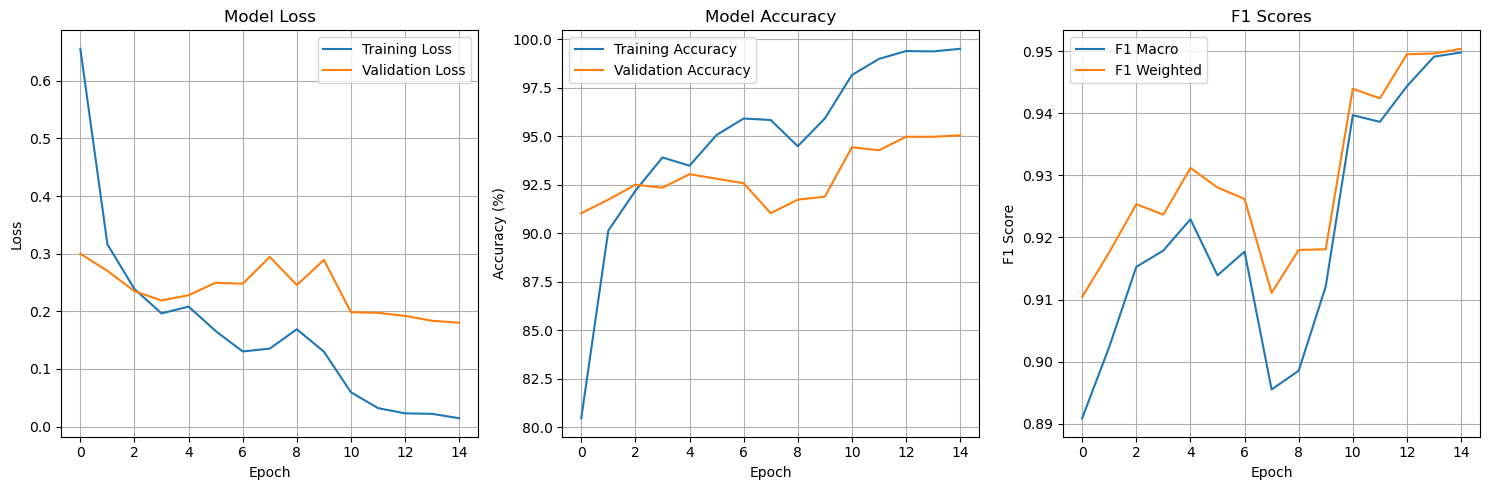

In [22]:
# Plot training history
plot_training_history(history)

# STEP 13: Model Evaluation

In [23]:
def evaluate_model(model, val_loader, device, class_names=None):
    """
    Comprehensive model evaluation: prints F1 scores, classification report,
    confusion matrix, and returns per-class F1 scores along with macro & weighted F1.
    """
    model.eval()
    all_predictions = []
    all_labels = []
    all_probabilities = []
    
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc='Evaluating'):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            probabilities = F.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
    
    # Calculate macro and weighted F1
    f1_macro = f1_score(all_labels, all_predictions, average='macro')
    f1_weighted = f1_score(all_labels, all_predictions, average='weighted')
    
    print(f"Final F1 Score (Macro): {f1_macro:.4f}")
    print(f"Final F1 Score (Weighted): {f1_weighted:.4f}")
    
    # Get classification report as dict
    report_dict = classification_report(all_labels, all_predictions, output_dict=True)
    
    print("\nPer-Class F1 Scores:")
    for cls_idx, metrics in report_dict.items():
        if cls_idx.isdigit():  # Only numeric classes
            label = f"{class_names[int(cls_idx)]}" if class_names else cls_idx
            print(f"Class {label}: F1 Score = {metrics['f1-score']:.4f}")
    
    # Print full classification report
    print("\nFull Classification Report:")
    print(classification_report(all_labels, all_predictions, target_names=class_names))
    
    # Confusion matrix
    cm = confusion_matrix(all_labels, all_predictions)
    plt.figure(figsize=(12, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    return f1_macro, f1_weighted, all_probabilities, report_dict

Evaluating: 100%|██████████| 61/61 [00:24<00:00,  2.49it/s]


Final F1 Score (Macro): 0.9666
Final F1 Score (Weighted): 0.9670

Per-Class F1 Scores:
Class Ink scenery: F1 Score = 0.9424
Class comic: F1 Score = 0.9744
Class cyberpunk: F1 Score = 0.9790
Class futuristic UI: F1 Score = 0.9863
Class lowpoly: F1 Score = 0.9352
Class oil painting: F1 Score = 0.9803
Class pixel: F1 Score = 0.9621
Class realistic: F1 Score = 0.9584
Class steampunk: F1 Score = 0.9893
Class water color: F1 Score = 0.9589

Full Classification Report:
               precision    recall  f1-score   support

  Ink scenery       0.96      0.93      0.94       283
        comic       1.00      0.95      0.97        40
    cyberpunk       0.99      0.97      0.98        72
futuristic UI       0.98      0.99      0.99       326
      lowpoly       0.94      0.93      0.94       109
 oil painting       0.97      0.99      0.98       328
        pixel       0.95      0.97      0.96       209
    realistic       0.94      0.98      0.96       177
    steampunk       0.99      0.99   

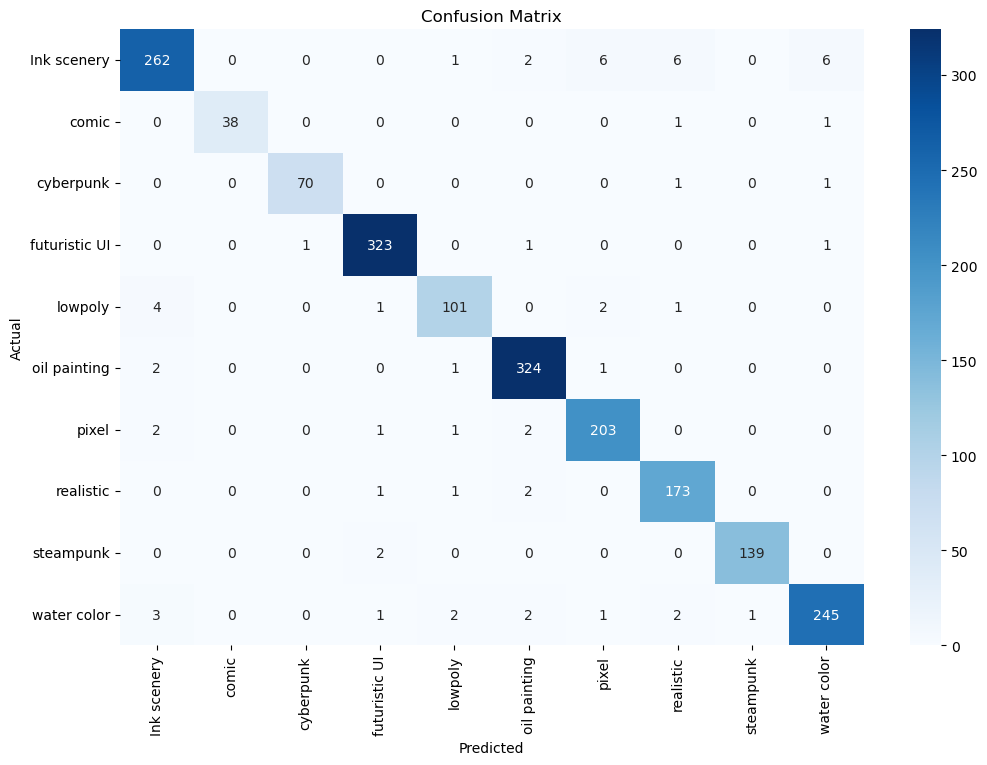

In [50]:
f1_macro, f1_weighted, all_probs, report_dict = evaluate_model(model, val_loader, device, class_names=LABELS)

# STEP 14: Test Data Prediction

In [24]:
def zclassifier_predict(model, data_loader, device):
    """
    Zclassifier prediction method - uses max logit values for confidence scoring
    """
    model.eval()
    all_predictions = []
    all_confidence_scores = []
    all_outputs = []
    all_logits = []
    
    with torch.no_grad():
        for batch_data in tqdm(data_loader, desc='Zclassifier Prediction'):
            images = batch_data[0].to(device)
            
            # Forward pass - get raw logits
            logits = model(images)
            
            # Get softmax probabilities for predictions
            probabilities = F.softmax(logits, dim=1)
            
            # Get predictions from probabilities
            _, predicted = torch.max(probabilities, 1)
            
            # Use max logit values as confidence scores (Zclassifier approach)
            max_logits, _ = torch.max(logits, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_confidence_scores.extend(max_logits.cpu().numpy())
            all_outputs.extend(probabilities.cpu().numpy())
            all_logits.extend(logits.cpu().numpy())
    
    return np.array(all_predictions), np.array(all_confidence_scores), np.array(all_outputs), np.array(all_logits)

In [25]:
print("Making predictions on test data using Zclassifier...")
test_predictions, test_logit_scores, test_outputs, test_all_logits = zclassifier_predict(model, test_loader, device)

Making predictions on test data using Zclassifier...


Zclassifier Prediction: 100%|██████████| 45/45 [00:17<00:00,  2.59it/s]


# STEP 15: Handle Unknown Class (11th Class)

In [226]:
print(LABEL2IDX)

{'Ink scenery': 0, 'comic': 1, 'cyberpunk': 2, 'futuristic UI': 3, 'lowpoly': 4, 'oil painting': 5, 'pixel': 6, 'realistic': 7, 'steampunk': 8, 'water color': 9}


In [227]:
def detect_unknown_class_zclassifier(predictions, logit_scores, threshold=2.0):
    """
    Detect potential unknown class based on max logit values (Zclassifier approach).
    
    Args: 
        predictions: Predicted class labels
        logit_scores: Maximum logit values for each prediction
        threshold: Logit threshold below which we classify as unknown
    
    Returns:
        Modified predictions with unknown class label (e.g., class 11)
    """
    modified_predictions = predictions.copy()
    modified_logits = logit_scores.copy()
    
    water_mask = predictions == 9
    modified_logits[water_mask] /= 1.2
    
    unknown_mask = modified_logits < threshold
    modified_predictions[unknown_mask] = 11  # unknown class
    
    print(f"Detected {np.sum(unknown_mask)} potential unknown class samples")
    print(f"Percentage of unknown samples: {np.sum(unknown_mask)/len(predictions)*100:.2f}%")
    print(f"Logit score statistics:")
    print(f"  Min: {np.min(logit_scores):.3f}")
    print(f"  Max: {np.max(logit_scores):.3f}")
    print(f"  Mean: {np.mean(logit_scores):.3f}")
    print(f"  Std: {np.std(logit_scores):.3f}")
    
    return modified_predictions

In [237]:
final_predictions = detect_unknown_class_zclassifier(test_predictions, test_logit_scores, threshold=5.5)

Detected 202 potential unknown class samples
Percentage of unknown samples: 14.32%
Logit score statistics:
  Min: 1.112
  Max: 46.256
  Mean: 12.667
  Std: 6.027


# STEP 16: Create Submission File

In [28]:
def create_submission(test_dataset, predictions, output_file="submission_zclass.csv", unknown_label="UNK"):
    """
    Create submission file using test dataset and predictions
    
    Args:
        test_dataset: ArtDataset instance for test data
        predictions: Array of predicted class indices
        output_file: Output CSV filename
        unknown_label: Label for unknown/out-of-distribution samples
    """
    submission_data = []

    # Use the provided LABELS list for class mapping
    LABELS = ['Ink scenery', 'comic', 'cyberpunk', 'futuristic UI', 'lowpoly', 'oil painting',
              'pixel', 'realistic', 'steampunk', 'water color']
    
    # Create idx_to_class mapping from LABELS
    idx_to_class = {i: label for i, label in enumerate(LABELS)}

    for i in range(len(test_dataset)):
        # Get UUID from dataset
        uuid = test_dataset.data.iloc[i]['uuid']
        
        pred_class_id = predictions[i]

        # If prediction is an unknown class index, name it "unknown"
        if pred_class_id in idx_to_class:
            pred_class_name = idx_to_class[pred_class_id]
        else:
            pred_class_name = unknown_label

        submission_data.append({
            "uuid": uuid,
            "style": pred_class_name
        })

    submission_df = pd.DataFrame(submission_data)
    submission_df.to_csv(output_file, index=False)
    print(f"Saved submission to {output_file}")
    print(f"Submission shape: {submission_df.shape}")
    print(f"Sample predictions:")
    print(submission_df.head())

    return submission_df

In [238]:
# Create submission file
submission = create_submission(test_dataset, final_predictions, output_file="submission_zclass_resize_2_water_color.csv")

Saved submission to submission_zclass_resize_2_water_color.csv
Submission shape: (1411, 2)
Sample predictions:
                                   uuid      style
0  ffcde60a-0158-4cc3-9b53-694bbddf5cb7        UNK
1  80804fd8-1350-4c19-bcf1-4a3d232cfa15    lowpoly
2  03bb4234-73a7-43cf-a5f5-32e0ebe89df2      pixel
3  0593a1cc-a6c9-4d52-aa2e-9cee91d2447e  steampunk
4  fa66a70b-eee6-4d18-bc41-fc90968097cc      pixel


In [ ]:
show_images_from_class(visual_loader, "Ink scenery", LABELS, num_images=12)

In [239]:
# Load the CSV
submission_dataset = pd.read_csv("submission_zclass_resize_2_water_color.csv")

In [240]:
print(submission['style'].value_counts())

style
UNK              202
realistic        150
water color      135
pixel            134
cyberpunk        131
Ink scenery      131
comic            124
steampunk        117
futuristic UI    106
oil painting      92
lowpoly           89
Name: count, dtype: int64


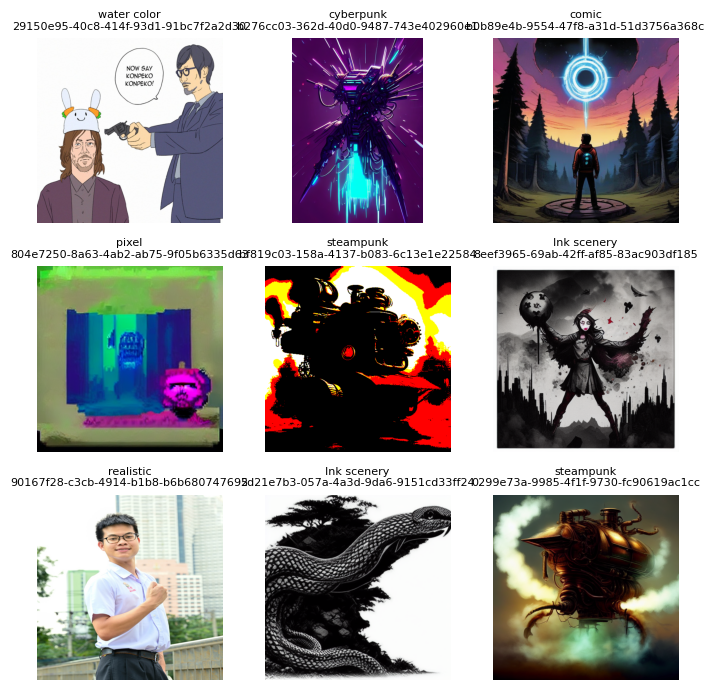

In [134]:
# Sample a few rows (you can adjust n)
sampled_df = submission_dataset.sample(n=9).reset_index(drop=True)

# Plot settings
plt.figure(figsize=(7, 7))  # Adjust size as needed

for i, row in sampled_df.iterrows():
    uuid = row['uuid']
    style = row['style']

    # Try PNG then JPG fallback
    img_path = os.path.join(DATA_DIR, f"{uuid}.png")
    image = Image.open(img_path)
    # Plot
    plt.subplot(3, 3, i + 1)  # 3 rows, 3 cols
    plt.imshow(image)
    plt.title(f"{style}\n{uuid}", fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()

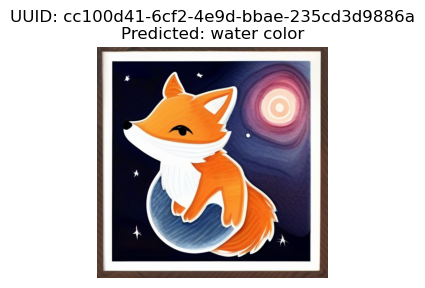

Logit scores for this image:
Ink scenery: -1.1113
comic: -2.0368
cyberpunk: -8.8658
futuristic UI: -0.5090
lowpoly: -2.8616
oil painting: -5.2002
pixel: -7.0344
realistic: -4.2732
steampunk: -8.1364
water color: 15.1490
water color : 15.1489896774292


In [224]:
logits_df = pd.DataFrame(test_all_logits, columns=LABELS)
logits_df['uuid'] = submission_dataset['uuid']
logits_df['predicted_style'] = submission_dataset['style']

# Pick a random row
# row = logits_df.sample(1).iloc[0]

# row = logits_df.loc[logits_df.predicted_style == 'UNK'].sample(1).iloc[0]

row = logits_df.loc[logits_df.predicted_style == 'water color'].sample(1).iloc[0]

# image_uuid ='108edc72-7363-4995-b14b-390057594f5e'
# row = logits_df.loc[logits_df.uuid == image_uuid].iloc[0]

# Show image
uuid = row['uuid']
image_path = f"./competition/image/{uuid}.png"
img = Image.open(image_path)

plt.figure(figsize=(3,3))
plt.imshow(img)
plt.axis("off")
plt.title(f"UUID: {uuid}\nPredicted: {row['predicted_style']}")
plt.show()

# Print logits
print("Logit scores for this image:")
m = [0, ""]
for label in LABELS:
    if (row[label] > m[0]):
        m[0] = row[label]
        m[1] = label
    print(f"{label}: {row[label]:.4f}")
print(f"{m[1]} : {m[0]}")

# STEP 17: Model Saving and Loading

In [ ]:
# Save the trained model
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'num_classes': num_classes,
    'f1_score': f1_weighted,
    'history': history
}, 'eff_b3_latest.pth')